Import Dependencies

In [ ]:
import numpy as np
import pickle
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
#download data from kaggle directly
import kagglehub
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.


In [ ]:
print(path)

/kaggle/input/fruits-fresh-and-rotten-for-classification


[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 ...

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  ...
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
(476, 458, 4)


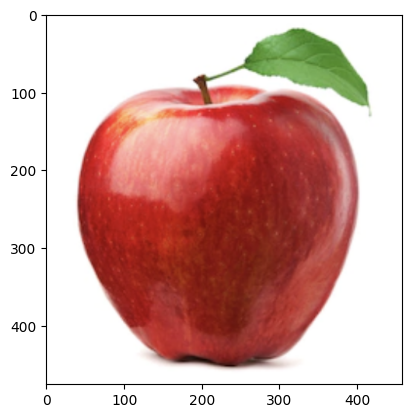

In [ ]:
img_path="/content/data/dataset/dataset/train/freshapples/Screen Shot 2018-06-08 at 4.59.36 PM.png"
img=mpimg.imread(img_path)
print(img)
print(img.shape)
plt.imshow(img)

[[[1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  ...
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]]

 [[1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  ...
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]]

 [[1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  ...
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]
  [1.         1.         0.99607843 1.        ]]

 ...

 [[0.42745098 0.34509805 0.3529412  1.        ]
  [0.7490196  0.6901961  0.7058824  1.        ]
  [0.88627

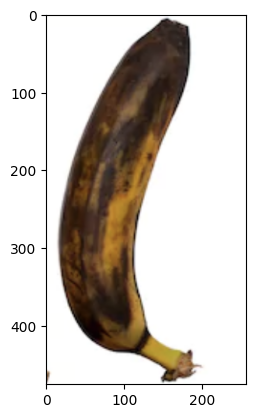

In [ ]:
img_path="/content/data/dataset/dataset/train/rottenbanana/Screen Shot 2018-06-12 at 8.47.57 PM.png"
img=mpimg.imread(img_path)
print(img)
print(img.shape)
plt.imshow(img)

In [ ]:
print(len(os.listdir("/content/data/dataset/dataset/train/freshapples")))
print(len(os.listdir("/content/data/dataset/dataset/train/freshbanana")))
print(len(os.listdir("/content/data/dataset/dataset/train/freshoranges")))
print(len(os.listdir("/content/data/dataset/dataset/train/rottenapples")))
print(len(os.listdir("/content/data/dataset/dataset/train/rottenbanana")))
print(len(os.listdir("/content/data/dataset/dataset/train/rottenoranges")))

1693
1581
1466
2342
2224
1595


In [ ]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    )

In [ ]:
dataset="/content/data/dataset/dataset/train"
train_data=data_gen.flow_from_directory(
   dataset,
    target_size=(128,128),
    batch_size=100,
    subset='training',
    color_mode='rgb',
    class_mode='categorical'
)

Found 10901 images belonging to 6 classes.


In [ ]:
print(train_data.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [ ]:
class_indices = {v: k for k, v in train_data.class_indices.items()}

In [ ]:
print(class_indices)

{0: 'freshapples', 1: 'freshbanana', 2: 'freshoranges', 3: 'rottenapples', 4: 'rottenbanana', 5: 'rottenoranges'}


In [ ]:
dataset_="/content/data/dataset/test"
test_data=data_gen.flow_from_directory(
   dataset_,
    target_size=(128,128),
    batch_size=100,
    color_mode='rgb',
     class_mode='categorical'
)

Found 2698 images belonging to 6 classes.


Building a model

In [ ]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPool2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPool2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(6, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#configuration process
model.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']

)


In [ ]:
history= model.fit(
    train_data, steps_per_epoch=train_data.samples//100 ,
    epochs=5
)

Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 304s 3s/step - accuracy: 0.7117 - loss: 0.9492
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 121us/step - accuracy: 0.8800 - loss: 0.3348
Epoch 3/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


109/109 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.8805 - loss: 0.3622
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 113us/step - accuracy: 0.9100 - loss: 0.2220
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.9256 - loss: 0.2058


In [ ]:
loss, accuracy=model.evaluate(test_data)
print (loss,accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9173 - loss: 0.2271
0.2270936518907547 0.917346179485321


In [ ]:
import pickle

pickle.dump(class_indices, open("classes.pkl", "wb"))

Building a predictive system

In [ ]:
def preprocceing_image(img_path) :
 img=Image.open(img_path)
 img=img.convert('RGB')
 resized_image=img.resize((128,128))
 img_array=np.asarray(resized_image)
 img_array=np.expand_dims(img_array,axis=0)
 rescaled_image=img_array.astype('float32')/255.
 return rescaled_image

def predicted_result(model,img_path,class_indices):
   image=preprocceing_image(img_path)
   prediction=model.predict(image)
   class_index=np.argmax(prediction,axis=1)[0]
   class_name=class_indices[class_index]
   return class_name


In [ ]:
#test
img_path="/content/data/dataset/dataset/test/rottenbanana/Screen Shot 2018-06-12 at 8.47.51 PM.png"
x= predicted_result(model,img_path,class_indices)
print(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
rottenbanana


In [ ]:
model.save("model_1.h5")